In [1]:
### SETUP 
import os
import numpy as np
import matplotlib.pyplot as plt
import os
import time
import sys
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np
from matplotlib import pyplot as plt
from torchsummary import summary
import helper
from tqdm import tqdm

ROOT = "/home/andre/courses/AdvMl_V26/A01_Uncertainty"
DATA = os.path.join(ROOT,"DATA")
LABEL_PATH = os.path.join(DATA,"labels.npy")
SPECTRA_PATH = os.path.join(DATA,"spectra.npy")

device = torch.device("cpu")

# Download data
from huggingface_hub import hf_hub_download
hf_hub_download(repo_id="simbaswe/galah4", filename="labels.npy", repo_type="dataset", local_dir=DATA)
hf_hub_download(repo_id="simbaswe/galah4", filename="spectra.npy", repo_type="dataset", local_dir=DATA)

#########################
# Format data
spectra = np.load(SPECTRA_PATH)
spectra_length = spectra.shape[1]
# labels: mass, age, l_bol, dist, t_eff, log_g, fe_h, SNR
labelNames = ["mass", "age", "l_bol", "dist", "t_eff", "log_g", "fe_h", "SNR"]
labels = np.load(LABEL_PATH)
# We only use the three labels: t_eff, log_g, fe_h
labelNames = labelNames[-4:-1]
labels = labels[:, -4:-1]
n_labels = labels.shape[1]
spectra = np.log(np.maximum(spectra, 0.2))
num_spectra = spectra.shape[0]

##############################
# Setup loaders

train_size = int(0.7*num_spectra)
val_size = int(0.15*num_spectra)
test_size = num_spectra-train_size-val_size
p = 0.95
y_data,ranges = helper.normalize(labels,p)

x_tensor = torch.tensor(spectra,dtype=torch.float32).view(num_spectra,-1).to(device)
#x_tensor = nn.MaxPool1d(2)(x_tensor)
y_tensor = torch.tensor(y_data,dtype=torch.float32).view(num_spectra,-1).to(device)
train_dataset, val_dataset, test_dataset = random_split(TensorDataset(x_tensor,y_tensor),[train_size,val_size,test_size])

batch_size = 64
train_loader = DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
val_loader = DataLoader(val_dataset,batch_size=batch_size,shuffle=False)
test_loader = DataLoader(test_dataset,batch_size=batch_size,shuffle=False)


In [2]:
Nc = 16

class simpleCNN(nn.Module):
    def __init__(self):
        super(simpleCNN,self).__init__()
        stride=1
        kernel_size = 6         
        self.net = nn.Sequential(
            nn.Conv1d(in_channels=1,out_channels=2**0*Nc,kernel_size=kernel_size,stride=stride),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(in_channels=2**0*Nc,out_channels=2**1*Nc,kernel_size=kernel_size,stride=stride),
            nn.ReLU(),
            nn.MaxPool1d(2),
            
            nn.Conv1d(in_channels=2**1*Nc,out_channels=2**2*Nc,kernel_size=kernel_size,stride=stride),
            nn.ReLU(),
            nn.MaxPool1d(2),
            
            nn.Conv1d(in_channels=2**2*Nc,out_channels=2**3*Nc,kernel_size=kernel_size,stride=stride),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Flatten(),
            nn.LazyLinear(64),
            nn.ReLU(),
            nn.LazyLinear(6),
        )
        
    def forward(self,x):
        return self.net(x)
    
def nll_loss(predictions,batch_labels,n_labels):
    mean = predictions[:,:n_labels]
    log_std = predictions[:,n_labels:]
    std = torch.exp(log_std)
    
    return torch.mean((0.5*((batch_labels-mean)/std)**2) + log_std)


In [3]:
num_epoch = 12
# Model initialization
model = simpleCNN()
model.to(device)
loss_func = nll_loss
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epoch, eta_min=1e-6)

In [4]:
best_val_loss = float("inf")
best_path = "best_model.pt"

train_losses, val_losses = [], []

for epoch in range(num_epoch):
    print(f"Epoch {epoch+1}, LR: {scheduler.get_last_lr()[0]:.6f}")

    # ---- Train ----
    model.train()
    train_loss = 0
    for batch_x, batch_y in tqdm(train_loader):
        batch_x = batch_x.unsqueeze(1)

        optimizer.zero_grad(set_to_none=True)
        predictions = model(batch_x)
        loss = loss_func(predictions, batch_y, n_labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)
    print(f"Loss {train_loss:.3f}")

    # ---- Validation ----
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x = batch_x.unsqueeze(1)
            predictions = model(batch_x)
            loss = loss_func(predictions, batch_y, n_labels)
            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)
    print(f"Val Loss {val_loss:.3f}")

    # ---- Save best ----
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_path)
        print(f"✅ Saved new best model (val_loss={val_loss:.4f})")

    scheduler.step()

Epoch 1, LR: 0.001000


100%|██████████| 98/98 [00:38<00:00,  2.58it/s]


Loss -0.498
Val Loss -0.786
✅ Saved new best model (val_loss=-0.7856)
Epoch 2, LR: 0.000983


100%|██████████| 98/98 [00:33<00:00,  2.92it/s]


Loss -1.224
Val Loss -1.635
✅ Saved new best model (val_loss=-1.6350)
Epoch 3, LR: 0.000933


...

Loss -2.719
Val Loss -2.425
Epoch 11, LR: 0.000068


100%|██████████| 98/98 [00:37<00:00,  2.61it/s]


Loss -2.766
Val Loss -2.431
Epoch 12, LR: 0.000018


100%|██████████| 98/98 [00:37<00:00,  2.59it/s]


Loss -2.796
Val Loss -2.431


In [5]:


all_pred = []
all_true = []

# Test data 
model.load_state_dict(torch.load(best_path))
model.eval()
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.unsqueeze(1)
        predictions = model(batch_x)
        all_pred.append(predictions.cpu())  # move to CPU to save GPU memory
        all_true.append(batch_y.cpu())

# Concatenate all batches into single tensors, then convert to numpy
all_pred = torch.cat(all_pred, dim=0).numpy()
all_true = torch.cat(all_true, dim=0).numpy()

# Rescale back to original unitsd
all_pred_original = helper.denormalize(all_pred[:,:n_labels],ranges)
all_true_original = helper.denormalize(all_true,ranges)

std_pred_original = np.exp(helper.denormalize_std(all_pred[:,n_labels:],ranges))

/tmp/ipykernel_405557/2195611115.py:22: RuntimeWarning: overflow encountered in exp
  std_pred_original = np.exp(helper.denormalize_std(all_pred[:,n_labels:],ranges))


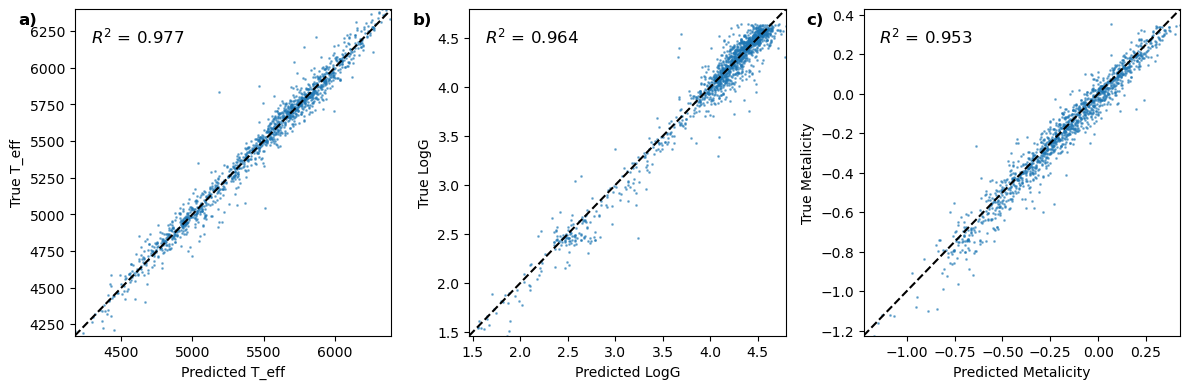

In [7]:
label_names = ["T_eff", "LogG","Metalicity"]

fig, axs = plt.subplots(1,3,figsize=(12,4))
alpha = 0.5
ax_labels = ["a)","b)","c)","d)","e)","f)"]

for k,ax in enumerate(axs):
    
    # Calculate data ranges 
    ax_max = np.maximum(all_true_original[:,k].max(),all_pred_original[:,k].max())
    ax_min = np.minimum(all_true_original[:,k].min(),all_pred_original[:,k].min())
    x = np.linspace(ax_min, ax_max, 100)
    ax.plot(x,x,color="black",linestyle="--")
    
    # add R2 to the plot
    ss_res = np.sum((all_true_original[:,k] - all_pred_original[:,k])**2)
    ss_tot = np.sum((all_true_original[:,k] - np.mean(all_true_original[:,k]))**2)
    r2 = 1 - ss_res/ss_tot
    ax.text(0.05, 0.95, f"$R^2$ = {r2:.3f}", transform=ax.transAxes, fontsize=12, verticalalignment='top')
    ax.text(-0.18,0.99, ax_labels[k], transform=ax.transAxes, fontsize=12, verticalalignment='top',fontdict={"weight":"bold"})
    
    ax.scatter(all_pred_original[:,k],all_true_original[:,k],alpha=alpha,s=1)
    ax.set_xlabel(f"Predicted {label_names[k]}")
    ax.set_ylabel(f"True {label_names[k]}")
    
    ax.set_xlim(ax_min, ax_max)
    ax.set_ylim(ax_min, ax_max)

plt.tight_layout()
plt.savefig("predictions.pdf",dpi=300)
plt.show()

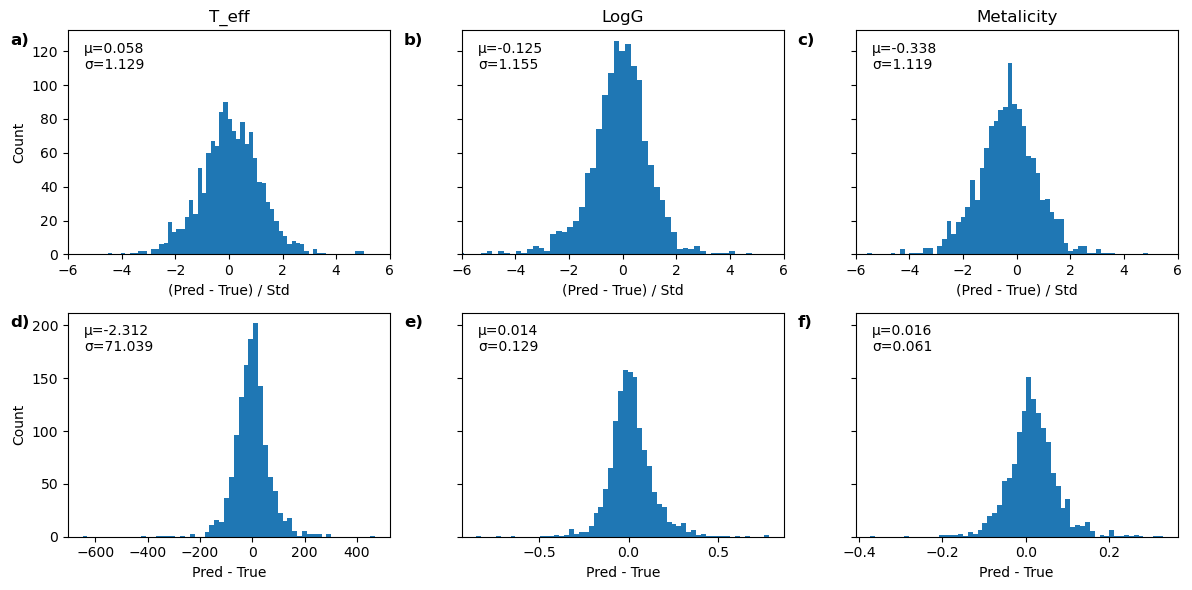

In [8]:
fig, axs = plt.subplots(2, 3, figsize=(12, 6), sharey='row')

bins_pull = 60
bins_res = 60

for k in range(3):
    
    # --- Data ---
    residuals_original = all_pred_original[:,k] - all_true_original[:,k]
    
    std = np.exp(all_pred[:,k+3])
    pulls = (all_pred[:,k]-all_true[:,k]) / std

    # Top row: pulls
    ax = axs[0, k]
    
    ax.hist(pulls, bins=bins_pull)
    ax.set_title(f"{label_names[k]}")
    ax.set_xlabel("(Pred - True) / Std")
    
    ax.text(0.05, 0.95,
            f"μ={np.mean(pulls):.3f}\nσ={np.std(pulls):.3f}",
            transform=ax.transAxes,
            fontsize=10,
            verticalalignment='top')
    ax.text(-0.18,0.99, ax_labels[k], transform=ax.transAxes, fontsize=12, verticalalignment='top',fontdict={"weight":"bold"})
    ax.set_xlim(-6,6)

    # Bottom row: residuals
    ax = axs[1, k]
    
    ax.hist(residuals_original, bins=bins_res)
    ax.set_xlabel("Pred - True")
    
    ax.text(0.05, 0.95,
            f"μ={np.mean(residuals_original):.3f}\nσ={np.std(residuals_original):.3f}",
            transform=ax.transAxes,
            fontsize=10,
            verticalalignment='top')
    ax.text(-0.18,0.99, ax_labels[k+3], transform=ax.transAxes, fontsize=12, verticalalignment='top',fontdict={"weight":"bold"})
    

axs[0,0].set_ylabel("Count")
axs[1,0].set_ylabel("Count")

plt.tight_layout()
plt.savefig("residuals_pulls.pdf", dpi=300)
plt.show()

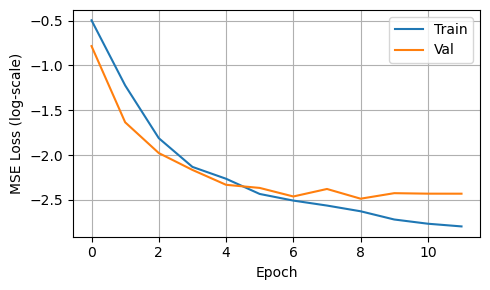

In [11]:
plt.figure(figsize=(5,3))
plt.plot(train_losses,label="Train")
plt.plot(val_losses,label="Val")
plt.ylabel("MSE Loss (log-scale)")
plt.xlabel("Epoch")
#plt.yscale("log")
plt.legend()
plt.tight_layout()
plt.grid()
plt.savefig("loss.pdf",dpi=300)
plt.show()

3